In [ ]:
# a simulated network



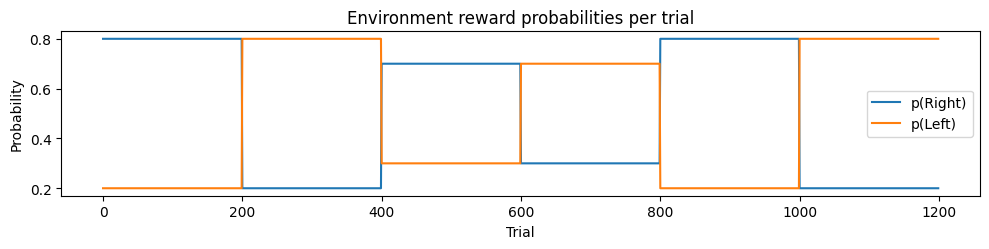

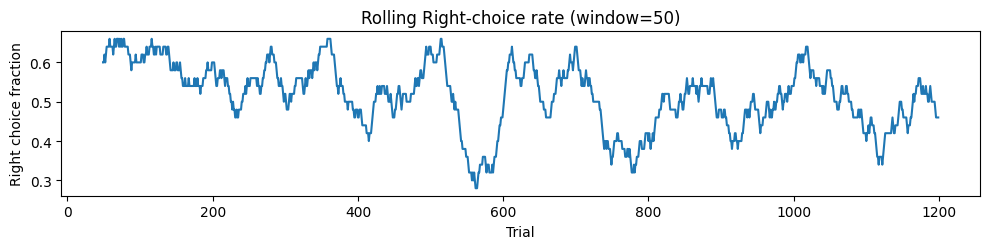

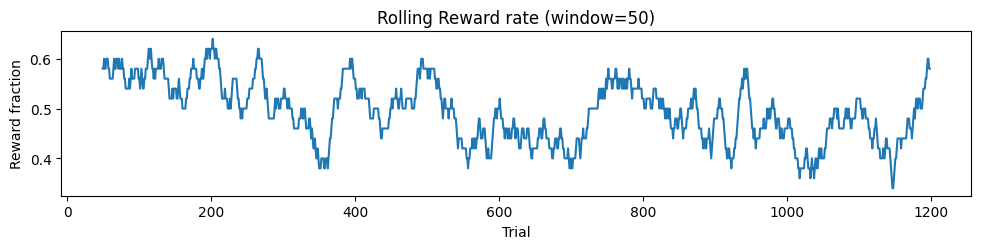

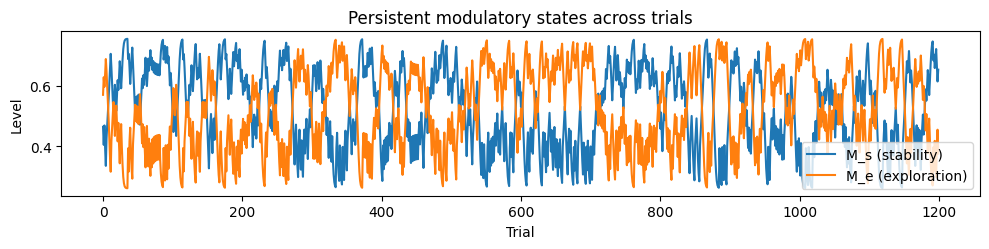

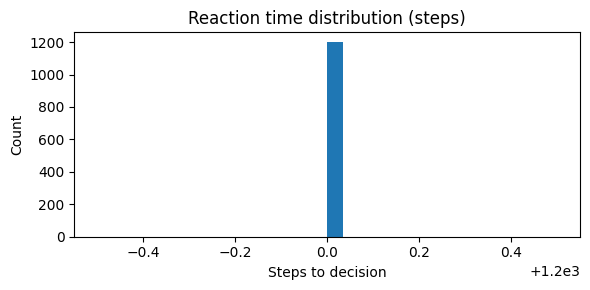

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [1]:
# Persistent Stay/Switch via Bistable Modulatory Loop — Simulation & Plots
# (Uses matplotlib with default settings; one chart per figure; no custom colors.)

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd
from math import isfinite
import io, os

# ----------------------------
# Model implementation
# ----------------------------

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

class WC_BistableModAgent:
    def __init__(
        self,
        # --- Decision (fixed) ---
        wEE=2.2, wEL=0.0, wEI=2.0, wIE=2.6, wII=0.5,
        bE=0.2, bI=0.0,
        tau_E=0.05, tau_I=0.02,

        # --- Modulatory flip-flop (persistent) ---
        tau_m=0.2,                 # intrinsic time constant of modulators
        w_ss=2.2, w_ee=2.2,        # self-excitation (M_s and M_e)
        w_se=2.0, w_es=2.0,        # mutual inhibition
        b_s=-0.2, b_e=-0.2,        # biases setting two clear basins
        # pulses
        pulse_amp_reward=2.5,      # drives M_s up
        pulse_amp_norew=2.5,       # drives M_e up
        pulse_dur=0.06,            # seconds of pulse injection

        # --- How modulators reshape the decision landscape ---
        gain_base=1.0,
        k_gain_s=1.2,              # M_s increases gain
        k_gain_e=1.0,              # M_e decreases gain (divisive)
        k_inh_s=0.4,               # M_s strengthens wEI
        sigma0=0.02,               # baseline noise
        k_noise_e=2.5,             # M_e increases noise

        # --- Integration / decision ---
        dt=0.001,
        T_decision=1.2,            # max time to decide per trial (s)
        x_thresh=0.35,             # threshold on D = E_R - E_L

        # --- Environment / RNG ---
        seed=7
    ):
        # Decision params
        self.wEE, self.wEL, self.wEI = wEE, wEL, wEI
        self.wIE, self.wII = wIE, wII
        self.bE, self.bI   = bE, bI
        self.tau_E, self.tau_I = tau_E, tau_I

        # Modulatory loop params
        self.tau_m = tau_m
        self.w_ss, self.w_ee = w_ss, w_ee
        self.w_se, self.w_es = w_se, w_es
        self.b_s,  self.b_e  = b_s,  b_e
        self.pulse_amp_reward = pulse_amp_reward
        self.pulse_amp_norew  = pulse_amp_norew
        self.dt = dt
        self.pulse_steps = max(1, int(np.round(pulse_dur / dt)))

        # Coupling from modulators to decision landscape
        self.gain_base = gain_base
        self.k_gain_s, self.k_gain_e = k_gain_s, k_gain_e
        self.k_inh_s = k_inh_s
        self.sigma0, self.k_noise_e = sigma0, k_noise_e

        # Integrator / RNG
        self.steps_per_trial = int(np.round(T_decision / dt))
        self.x_thresh = x_thresh
        self.rng = np.random.default_rng(seed)

        # --- States ---
        # Decision pools
        self.E_R = 0.1; self.E_L = 0.1; self.I = 0.1
        # Modulators (start neutral)
        self.M_s = 0.0; self.M_e = 0.0

    # ---------- Effective parameters ----------
    def _effective_gain(self):
        # M_s up => multiply; M_e up => divide (competition-like)
        g = self.gain_base * (1.0 + self.k_gain_s * self.M_s) / (1.0 + self.k_gain_e * self.M_e)
        return max(0.0, g)

    def _effective_wEI(self):
        # Stronger inhibition in stability mode deepens wells
        return self.wEI * (1.0 + self.k_inh_s * self.M_s)

    def _effective_sigma(self):
        # Higher noise in exploration mode flattens wells functionally
        return self.sigma0 * (1.0 + self.k_noise_e * self.M_e)

    # ---------- One integrator step ----------
    def _step_decision(self, ext_bias=0.0):
        g   = self._effective_gain()
        wEI = self._effective_wEI()
        sig = self._effective_sigma()

        inp_R = g * ( self.wEE*self.E_R + self.wEL*self.E_L - wEI*self.I + self.bE + ext_bias )
        inp_L = g * ( self.wEE*self.E_L + self.wEL*self.E_R - wEI*self.I + self.bE - ext_bias )

        fR, fL = sigmoid(inp_R), sigmoid(inp_L)

        inp_I = self.wIE*(self.E_R + self.E_L) - self.wII*self.I + self.bI
        fI = sigmoid(inp_I)

        # Euler–Maruyama
        self.E_R += (-self.E_R + fR)/self.tau_E * self.dt + self._effective_sigma()*np.sqrt(self.dt)*self.rng.normal()
        self.E_L += (-self.E_L + fL)/self.tau_E * self.dt + self._effective_sigma()*np.sqrt(self.dt)*self.rng.normal()
        self.I   += (-self.I  + fI )/self.tau_I * self.dt

        # clamp for interpretability
        self.E_R = float(np.clip(self.E_R, 0.0, 1.0))
        self.E_L = float(np.clip(self.E_L, 0.0, 1.0))
        self.I   = float(np.clip(self.I,   0.0, 1.0))

    def _step_modulators(self, I_rew=0.0, I_norew=0.0):
        """
        One Euler step for the bistable modulatory flip-flop.
        """
        # Inputs with self-excitation and mutual inhibition
        z_s = self.w_ss*self.M_s - self.w_se*self.M_e + self.b_s + I_rew
        z_e = self.w_ee*self.M_e - self.w_es*self.M_s + self.b_e + I_norew
        s_s, s_e = sigmoid(z_s), sigmoid(z_e)

        self.M_s += (-self.M_s + s_s)/self.tau_m * self.dt
        self.M_e += (-self.M_e + s_e)/self.tau_m * self.dt

        # keep in [0,1]
        self.M_s = float(np.clip(self.M_s, 0.0, 1.0))
        self.M_e = float(np.clip(self.M_e, 0.0, 1.0))

    # ---------- Decide within one trial ----------
    def decide(self):
        for step in range(self.steps_per_trial):
            self._step_modulators()       # modulators evolve continuously
            self._step_decision(ext_bias=0.0)
            D = self.E_R - self.E_L
            if D >= self.x_thresh: return +1, step + 1
            if D <= -self.x_thresh: return -1, step + 1
        return (+1 if (self.E_R - self.E_L) >= 0 else -1), self.steps_per_trial

    # ---------- Apply brief outcome pulse, then allow loop to settle ----------
    def outcome_pulse(self, reward):
        # Inject pulse to M_s (reward) or M_e (no-reward) for a few integration steps
        I_rew = self.pulse_amp_reward if reward==1 else 0.0
        I_nrw = self.pulse_amp_norew if reward==0 else 0.0
        for _ in range(self.pulse_steps):
            self._step_modulators(I_rew, I_nrw)
            self._step_decision(ext_bias=0.0)  # let decision state feel the shift

        # After the pulse ends, modulators remain near their basin until flipped

    # ---------- One full bandit trial ----------
    def act_and_update(self, pR_env, pL_env):
        choice, rt = self.decide()
        reward = 1 if (self.rng.uniform() < (pR_env if choice==+1 else pL_env)) else 0
        self.outcome_pulse(reward)
        return choice, reward, rt, float(self.M_s), float(self.M_e), float(self.E_R - self.E_L)

# ----------------------------
# Environment + simulation
# ----------------------------
def make_bandit_schedule(T=1000, block_len=200, probs=((0.8,0.2),(0.2,0.8),(0.7,0.3),(0.3,0.7))):
    pR = np.zeros(T); pL = np.zeros(T)
    nb = int(np.ceil(T/block_len))
    for b in range(nb):
        pr, pl = probs[b % len(probs)]
        s, e = b*block_len, min((b+1)*block_len, T)
        pR[s:e] = pr; pL[s:e] = pl
    return pR, pL

def run_session_persistent(
    T_trials=1000, block_len=200,
    probs=((0.8,0.2),(0.2,0.8),(0.7,0.3),(0.3,0.7)),
    seed=7, agent_kwargs=None
):
    pR, pL = make_bandit_schedule(T_trials, block_len, probs)
    ag = WC_BistableModAgent(seed=seed, **(agent_kwargs or {}))

    choices = np.zeros(T_trials, int)
    rewards = np.zeros(T_trials, int)
    rts     = np.zeros(T_trials, int)
    Ms_hist = np.zeros(T_trials, float)
    Me_hist = np.zeros(T_trials, float)
    D_hist  = np.zeros(T_trials, float)

    for t in range(T_trials):
        c, r, rt, Ms, Me, D = ag.act_and_update(pR[t], pL[t])
        choices[t], rewards[t], rts[t] = c, r, rt
        Ms_hist[t], Me_hist[t], D_hist[t] = Ms, Me, D

    return dict(pR=pR, pL=pL, choices=choices, rewards=rewards, rts=rts,
                M_s=Ms_hist, M_e=Me_hist, D=D_hist)

# ----------------------------
# Run a simulation
# ----------------------------
res = run_session_persistent(
    T_trials=1200,
    block_len=200,
    probs=((0.8,0.2),(0.2,0.8),(0.7,0.3),(0.3,0.7)),
    seed=11,
    agent_kwargs=dict(
        # keep defaults; tweak a bit for demonstrative persistence
        pulse_amp_reward=2.8,
        pulse_amp_norew=2.8,
        k_noise_e=2.8,
        k_gain_s=1.2,
        k_gain_e=1.0,
        tau_m=0.25
    )
)

# ----------------------------
# Metrics
# ----------------------------
choices = res["choices"]
rewards = res["rewards"]
rts = res["rts"]
pR = res["pR"]; pL = res["pL"]
Ms = res["M_s"]; Me = res["M_e"]

right_rate = (choices==+1).mean()
mean_reward = rewards.mean()
mean_rt_steps = rts.mean()
mode_state = (Ms > Me).astype(int)  # 1 = stability mode, 0 = exploration mode
mode_switches = int(np.sum(np.abs(np.diff(mode_state))==1))

# Rolling choice average (Right fraction) for visualization
window = 50
pad = window-1
roll_right = np.convolve((choices==+1).astype(float), np.ones(window)/window, mode='valid')
roll_reward = np.convolve(rewards.astype(float), np.ones(window)/window, mode='valid')

# ----------------------------
# Plots
# ----------------------------

# 1) Environment reward probabilities
plt.figure(figsize=(10, 2.6))
plt.plot(pR, label="p(Right)")
plt.plot(pL, label="p(Left)")
plt.title("Environment reward probabilities per trial")
plt.xlabel("Trial")
plt.ylabel("Probability")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Rolling right-choice rate
plt.figure(figsize=(10, 2.6))
plt.plot(np.arange(len(roll_right)) + pad, roll_right)
plt.title(f"Rolling Right-choice rate (window={window})")
plt.xlabel("Trial")
plt.ylabel("Right choice fraction")
plt.tight_layout()
plt.show()

# 3) Rolling reward rate
plt.figure(figsize=(10, 2.6))
plt.plot(np.arange(len(roll_reward)) + pad, roll_reward)
plt.title(f"Rolling Reward rate (window={window})")
plt.xlabel("Trial")
plt.ylabel("Reward fraction")
plt.tight_layout()
plt.show()

# 4) Modulatory states over trials
plt.figure(figsize=(10, 2.6))
plt.plot(Ms, label="M_s (stability)")
plt.plot(Me, label="M_e (exploration)")
plt.title("Persistent modulatory states across trials")
plt.xlabel("Trial")
plt.ylabel("Level")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Reaction time histogram (in steps); convert to seconds using dt from the class (dt=0.001)
plt.figure(figsize=(6, 3))
plt.hist(rts, bins=30)
plt.title("Reaction time distribution (steps)")
plt.xlabel("Steps to decision")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ----------------------------
# Summary table
# ----------------------------
summary_df = pd.DataFrame({
    "Right rate": [right_rate],
    "Mean reward": [mean_reward],
    "Mean RT (steps)": [mean_rt_steps],
    "Mode switches (M_s vs M_e)": [mode_switches]
})
#from caas_jupyter_tools import display_dataframe_to_user
#display_dataframe_to_user("Simulation summary (persistent modulatory loop)", summary_df)

print("Done: simulation complete.")
